In [1]:
#Step1:Importing libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
#Step2:loading dataset
dataset = pd.read_csv(r'C:\Surya\data.csv')
dataset

,Country,Age,Salary,Purchased
0,France,44.0,72000.0,No
1,Spain,27.0,48000.0,Yes
2,Germany,30.0,54000.0,No
3,Spain,38.0,61000.0,No
4,Germany,40.0,NaN,Yes
5,France,35.0,58000.0,Yes
6,Spain,NaN,52000.0,No
7,France,48.0,79000.0,Yes
8,Germany,50.0,83000.0,No
9,France,37.0,67000.0,Yes


In [ ]:
##Step3: Check for null values
dataset.isnull().sum()

Country      0
Age          1
Salary       1
Purchased    0
dtype: int64

<Axes: xlabel='Age', ylabel='Count'>

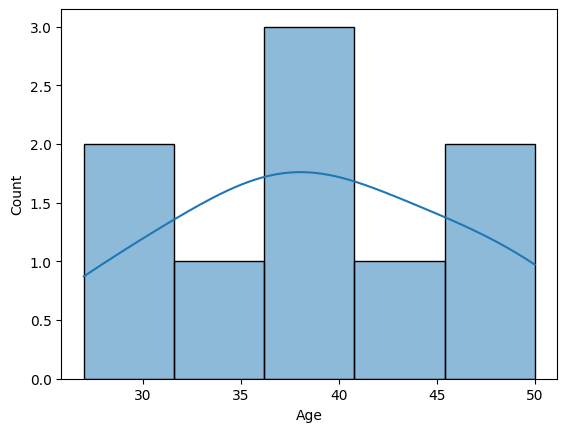

In [4]:
#step4:Analyse the data to identify the starategy to fill null values
import seaborn as sns
sns.histplot(data=dataset, x='Age', kde=True)

<Axes: xlabel='Salary', ylabel='Count'>

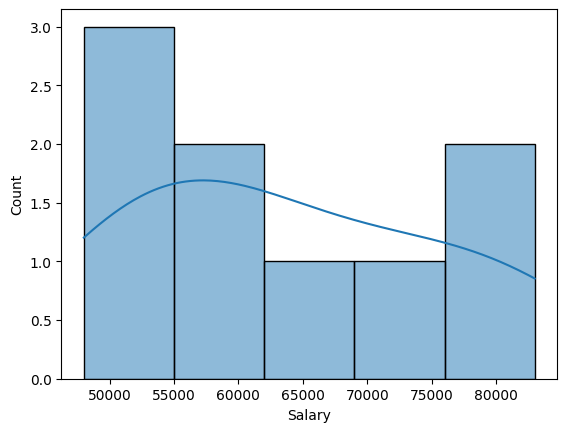

In [5]:
sns.histplot(data=dataset, x='Salary', kde=True)

In [9]:
#step5:Filling missing values with mean or median or mode

dataset['Age'] = dataset['Age'].fillna(dataset['Age'].mean())

In [10]:
dataset['Age']= dataset['Age'].round()
dataset['Age']

0    44.0
1    27.0
2    30.0
3    38.0
4    40.0
5    35.0
6    39.0
7    48.0
8    50.0
9    37.0
Name: Age, dtype: float64

In [11]:
dataset['Salary'] =  dataset['Salary'].fillna(dataset['Salary'].median())
dataset['Salary']

0    72000.0
1    48000.0
2    54000.0
3    61000.0
4    61000.0
5    58000.0
6    52000.0
7    79000.0
8    83000.0
9    67000.0
Name: Salary, dtype: float64

In [12]:
dataset

,Country,Age,Salary,Purchased
0,France,44.0,72000.0,No
1,Spain,27.0,48000.0,Yes
2,Germany,30.0,54000.0,No
3,Spain,38.0,61000.0,No
4,Germany,40.0,61000.0,Yes
5,France,35.0,58000.0,Yes
6,Spain,39.0,52000.0,No
7,France,48.0,79000.0,Yes
8,Germany,50.0,83000.0,No
9,France,37.0,67000.0,Yes


In [ ]:
#Step6: Handling categorical variables


#Two types of categorical varibales

#1.Nominal variables  --> ex: country, colours,gender,natoinality --> (var whihc dont hvae any natural order)
#2.Ordinal variables  --> ex: purchased,rank,sentiment(pos,neg,neut) -->(They have some order or ranking)


SyntaxError: invalid syntax (429188868.py, line 4)

In [16]:
dataset

,Country,Age,Salary,Purchased
0,France,44.0,72000.0,No
1,Spain,27.0,48000.0,Yes
2,Germany,30.0,54000.0,No
3,Spain,38.0,61000.0,No
4,Germany,40.0,61000.0,Yes
5,France,35.0,58000.0,Yes
6,Spain,39.0,52000.0,No
7,France,48.0,79000.0,Yes
8,Germany,50.0,83000.0,No
9,France,37.0,67000.0,Yes


In [ ]:
#country falls under nominal variables
                           country_0 country_1 country_2
France- 1   -->  0 0 1  --> 0          0         1 
Spain-  2   -->  0 1 0  --> 0          1         0
Germany-3   -->  1 0 0  --> 1          0         0

In [29]:
#seperate independent and dependent variables
x = dataset.iloc[:,0:3].values
x

array([['France', 44.0, 72000.0],
       ['Spain', 27.0, 48000.0],
       ['Germany', 30.0, 54000.0],
       ['Spain', 38.0, 61000.0],
       ['Germany', 40.0, 61000.0],
       ['France', 35.0, 58000.0],
       ['Spain', 39.0, 52000.0],
       ['France', 48.0, 79000.0],
       ['Germany', 50.0, 83000.0],
       ['France', 37.0, 67000.0]], dtype=object)

In [30]:
y = dataset.iloc[:,-1].values
y

<StringArray>
['No', 'Yes', 'No', 'No', 'Yes', 'Yes', 'No', 'Yes', 'No', 'Yes']
Length: 10, dtype: str

In [31]:
#Encoding categorical variables(step 6)
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder  #this will convert to country col to binary


In [32]:
ct  = ColumnTransformer([("on",OneHotEncoder(),[0])],remainder="passthrough")
x =  ct.fit_transform(x)
x

array([[1.0, 0.0, 0.0, 44.0, 72000.0],
       [0.0, 0.0, 1.0, 27.0, 48000.0],
       [0.0, 1.0, 0.0, 30.0, 54000.0],
       [0.0, 0.0, 1.0, 38.0, 61000.0],
       [0.0, 1.0, 0.0, 40.0, 61000.0],
       [1.0, 0.0, 0.0, 35.0, 58000.0],
       [0.0, 0.0, 1.0, 39.0, 52000.0],
       [1.0, 0.0, 0.0, 48.0, 79000.0],
       [0.0, 1.0, 0.0, 50.0, 83000.0],
       [1.0, 0.0, 0.0, 37.0, 67000.0]], dtype=object)

In [33]:
#removing of dummy variable
x= x[:,1:]
x

array([[0.0, 0.0, 44.0, 72000.0],
       [0.0, 1.0, 27.0, 48000.0],
       [1.0, 0.0, 30.0, 54000.0],
       [0.0, 1.0, 38.0, 61000.0],
       [1.0, 0.0, 40.0, 61000.0],
       [0.0, 0.0, 35.0, 58000.0],
       [0.0, 1.0, 39.0, 52000.0],
       [0.0, 0.0, 48.0, 79000.0],
       [1.0, 0.0, 50.0, 83000.0],
       [0.0, 0.0, 37.0, 67000.0]], dtype=object)

In [34]:
from sklearn.preprocessing import LabelEncoder
lb = LabelEncoder()
y =lb.fit_transform(y)
y

array([0, 1, 0, 0, 1, 1, 0, 1, 0, 1])

In [35]:
#Step7 : Splitting data into train and test
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test =  train_test_split(x,y,test_size=0.2,random_state=0)
x_train


array([[1.0, 0.0, 40.0, 61000.0],
       [0.0, 0.0, 37.0, 67000.0],
       [0.0, 1.0, 27.0, 48000.0],
       [0.0, 1.0, 39.0, 52000.0],
       [0.0, 0.0, 48.0, 79000.0],
       [0.0, 1.0, 38.0, 61000.0],
       [0.0, 0.0, 44.0, 72000.0],
       [0.0, 0.0, 35.0, 58000.0]], dtype=object)

In [36]:
x_train.shape

(8, 4)

In [37]:
y_train

array([1, 1, 1, 0, 1, 0, 0, 1])

In [38]:
x_test

array([[1.0, 0.0, 30.0, 54000.0],
       [1.0, 0.0, 50.0, 83000.0]], dtype=object)

In [39]:
y_test

array([0, 0])